# Data loading

In [1]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Drive path (for Colab)
# file_path = "/content/drive/MyDrive/Data/tourism-demand-forecast-japan/"
file_path = "../data/"  # for GitHub execution

df = pd.read_csv(file_path + "japan_inbound_visitors_monthly.csv")

# Visitor arrivals

In [142]:
# 月データを作る
df["Month"] = df["Month (abbr)"] + " " + df["Year"].astype(str)

# ピリオドを削除
df["Month"] = df["Month"].str.replace(".", "", regex=False)

# datetime型に変換
df["Month"] = pd.to_datetime(df["Month"], format="%b %Y")

# Missing values represent months where arrivals from a country were zero.
# Therefore, NaN values are replaced with 0.
# int型に変換
df["Visitor Arrivals"] = (
    df["Visitor Arrivals"]
    .astype(str)
    .str.replace(",", "")
    .replace("nan", "0")
    .astype(int)
)

In [144]:
# Step1 月ごとの訪日客総数を作る
monthly_total = df.groupby("Month")["Visitor Arrivals"].sum()

# Step2 DataFrameに戻す
monthly_total = monthly_total.reset_index()

# Step3 時系列indexにする
monthly_total = monthly_total.set_index("Month")

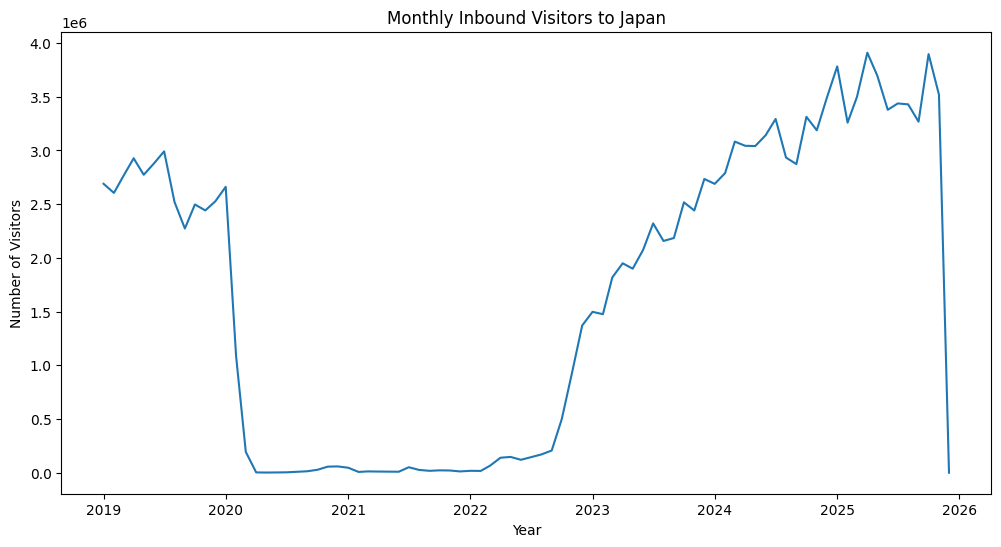

In [148]:
# Step4 グラフ
plt.figure(figsize=(12,6))

plt.plot(monthly_total.index, monthly_total["Visitor Arrivals"])

plt.title("Monthly Inbound Visitors to Japan")
plt.xlabel("Year")
plt.ylabel("Number of Visitors")

plt.savefig(file_path + "monthly_inbound_visitors.png", dpi=300)

plt.show()

# Seasonality analysis

In [146]:
# 月を抽出
monthly_total["month"] = monthly_total.index.month

# visitorの月平均を作る
seasonality = monthly_total.groupby("month")["Visitor Arrivals"].mean()

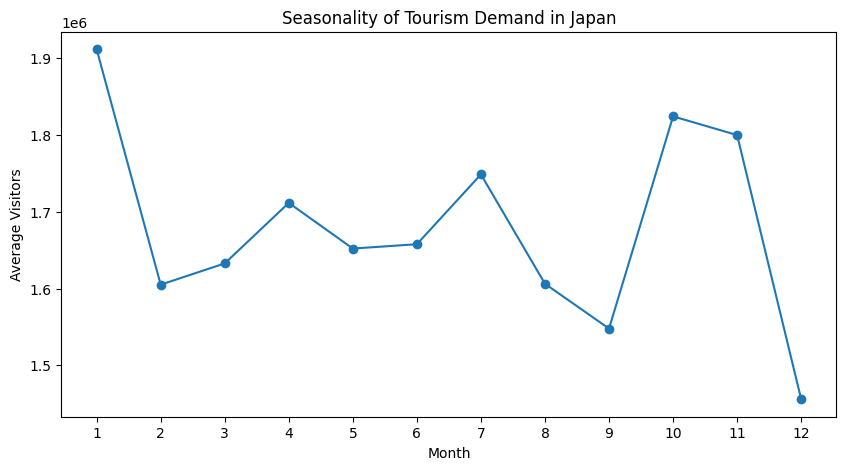

In [149]:
# グラフ
plt.figure(figsize=(10,5))
plt.plot(seasonality.index, seasonality.values, marker="o")

plt.title("Seasonality of Tourism Demand in Japan")
plt.xlabel("Month")
plt.ylabel("Average Visitors")

plt.xticks(range(1,13))

plt.savefig(file_path + "seasonality_of_tourism_demand.png", dpi=300)

plt.show()

# 為替データ取得

In [155]:
# USD/JPY 月次データを取得します。
# by Federal Reserve Bank of St. Louis

import pandas as pd

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXJPUS"

exchange = pd.read_csv(url)

exchange["observation_date"] = pd.to_datetime(exchange["observation_date"])

exchange = exchange.set_index("observation_date")

# 月次平均
exchange_monthly = exchange.resample("MS").mean()

# 訪日客 × 為替

In [151]:
# Join
data = monthly_total.join(exchange_monthly)

# remove month
data[["Visitor Arrivals", "DEXJPUS"]].corr()

data.corr()

,Visitor Arrivals,month,DEXJPUS
Visitor Arrivals,1.000000,-0.023853,0.591917
month,-0.023853,1.000000,0.127061
DEXJPUS,0.591917,0.127061,1.000000


### Visitor arrivals and exchange rate

The correlation between monthly visitor arrivals and USD/JPY is moderately positive (about 0.59).
This suggests that inbound tourism tends to recover during periods of yen depreciation.
However, this result should be interpreted carefully because the sample period includes the COVID-19 shock and other structural changes.

### visualization

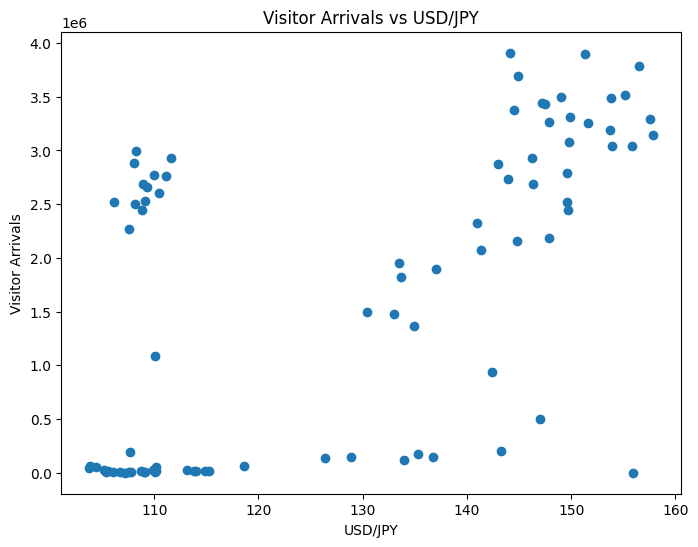

In [152]:
# 為替と訪日客の関係
plt.figure(figsize=(8,6))
plt.scatter(data["DEXJPUS"], data["Visitor Arrivals"])
plt.xlabel("USD/JPY")
plt.ylabel("Visitor Arrivals")
plt.title("Visitor Arrivals vs USD/JPY")
plt.show()

# REER (Real Effective Exchange Rate)

In [156]:
import pandas as pd

reer = pd.read_csv(file_path + "BIS_REER_Japan.csv", skiprows=3)

reer = reer[["TIME_PERIOD:Period", "OBS_VALUE:Value"]].copy()

reer = reer.rename(columns={
    "TIME_PERIOD:Period": "date",
    "OBS_VALUE:Value": "reer"
})

In [157]:
reer["date"] = pd.to_datetime(reer["date"])
reer["reer"] = pd.to_numeric(reer["reer"], errors="coerce")
reer = reer.set_index("date").sort_index()
reer.index = reer.index.to_period("M").to_timestamp()

### visualization

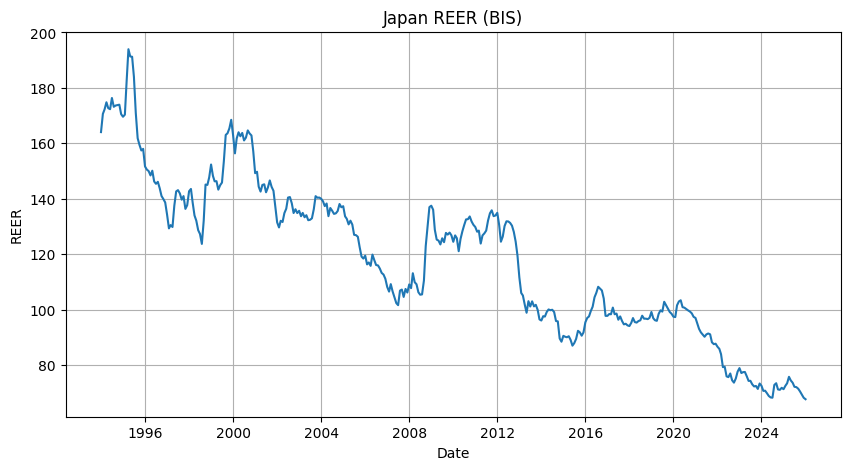

In [158]:
plt.figure(figsize=(10, 5))
plt.plot(reer.index, reer["reer"])
plt.title("Japan REER (BIS)")
plt.xlabel("Date")
plt.ylabel("REER")
plt.grid(True)
plt.show()

# Google Trends

### Google Trends取得
- Japan travel
- Visit Japan
- Japan rail pass

### Step2
Visitor + REER + Trends

統合データ作成

### Step3
SARIMAX

In [159]:
travel = pd.read_csv(file_path + "Japan_travel.csv")
visit = pd.read_csv(file_path + "Visit_Japan.csv")
rail = pd.read_csv(file_path + "Japan_rail_pass.csv")

# time型
travel["Time"] = pd.to_datetime(travel["Time"])
visit["Time"] = pd.to_datetime(visit["Time"])
rail["Time"] = pd.to_datetime(rail["Time"])

# merge
df_trends = travel.merge(visit, on="Time")
df_trends = df_trends.merge(rail, on="Time")

df_trends = df_trends.set_index("Time")

df_trends.index = df_trends.index.to_period("M").to_timestamp()

# 結合

In [102]:
# 国別 → 合計に変換する
visitors = df.groupby("Month")["Visitor Arrivals"].sum()

# DataFrameに変換
visitors = visitors.to_frame(name="visitors")

# 結合 (2019/1/1 - 2025/12/31)
df_model = visitors.join(reer, how="inner")
df_model = df_model.join(df_trends, how="inner")

print(reer.shape, visitors.shape, df_trends.shape, df_model.shape)

df_model.tail()

# 各月の訪日客数（目的変数）
# 各月のREER
# 各月の検索需要

(385, 1) (84, 1) (87, 3) (84, 5)


,visitors,reer,Japan travel,Visit Japan,Japan rail pass
2025-08-01,3428406,72.10,9,36,30
2025-09-01,3267228,71.53,10,45,29
2025-10-01,3896524,70.55,14,43,46
2025-11-01,3518195,69.40,62,51,51
2025-12-01,0,68.26,100,51,38


In [160]:
#　ラグ変数の追加
df_model["travel_lag1"] = df_model["Japan travel"].shift(1)
df_model["travel_lag2"] = df_model["Japan travel"].shift(2)

df_model["visit_lag1"] = df_model["Visit Japan"].shift(1)
df_model["visit_lag2"] = df_model["Visit Japan"].shift(2)

df_model["rail_lag1"] = df_model["Japan rail pass"].shift(1)
df_model["rail_lag2"] = df_model["Japan rail pass"].shift(2)

df_model = df_model[df_model["visitors"] > 0]

df_model = df_model.dropna()

# SARIMAX

In [113]:
# 目的変数と説明変数を分ける

y = df_model["visitors"] # 目的変数：訪日客数

X = df_model[
    [
        "reer",
        "travel_lag1",
        "travel_lag2",
        "visit_lag1",
        "visit_lag2",
        "rail_lag1",
        "rail_lag2"
    ]
]

In [114]:
# SARIMAXモデル
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y,
    exog=X,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [115]:
# モデル学習
results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                           visitors   No. Observations:                   81
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -933.512
Date:                            Sat, 14 Mar 2026   AIC                           1891.025
Time:                                    13:31:11   BIC                           1917.659
Sample:                                03-01-2019   HQIC                          1901.578
                                     - 11-01-2025                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
reer        -2.233e+04    2.2e+04     -1.017      0.309   -6.54e+04    2.07e+04
travel_lag1  -3.11e+04   1.91e+0

In [116]:
# 予測
pred = results.predict(
    start=y.index[0],
    end=y.index[-1],
    exog=X
)

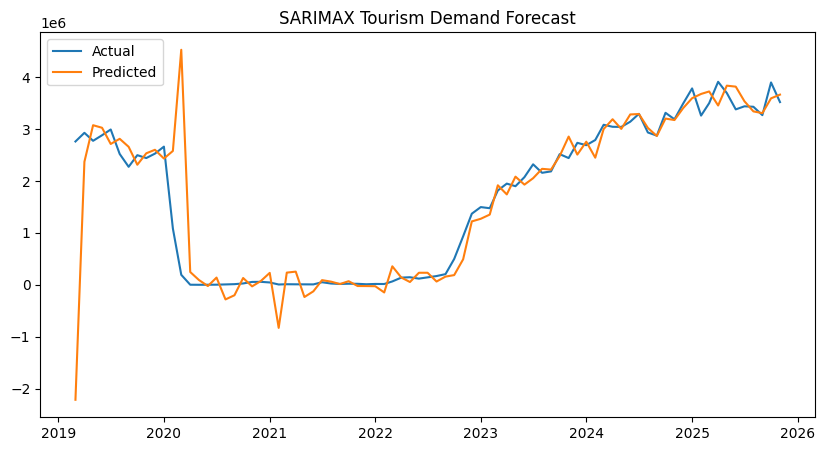

In [135]:
# 可視化
plt.figure(figsize=(10,5))

plt.plot(y, label="Actual")
plt.plot(pred, label="Predicted")

plt.legend()
plt.title("SARIMAX Tourism Demand Forecast")

plt.savefig(file_path + "tourism_demand_forecast.png", dpi=300)

plt.show()

In [121]:
# 予測精度
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
mape = np.mean(np.abs((y - pred) / y)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 298214.7877611638
RMSE: 782995.7461278215
MAPE: 611.9449583359225


# 未来予測（Forecasting）

In [122]:
future_exog = X.tail(1).values
future_exog = np.repeat(future_exog, 6, axis=0)

In [123]:
# 予測
forecast = results.get_forecast(
    steps=6,
    exog=future_exog
)

forecast_mean = forecast.predicted_mean

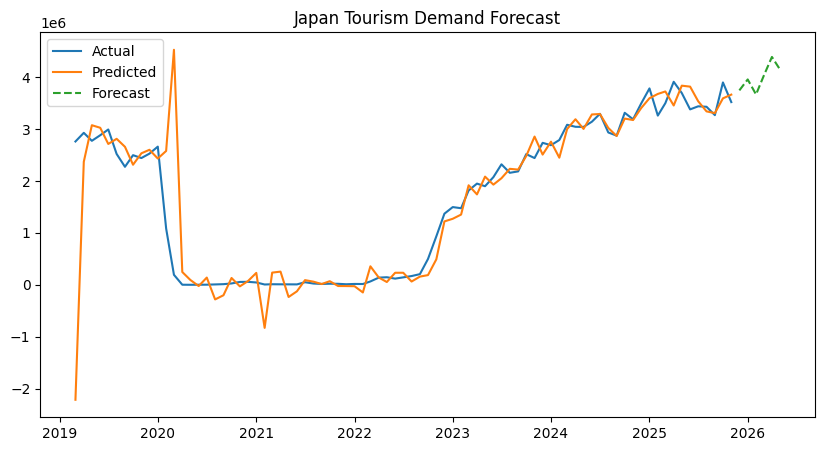

In [136]:
# 未来グラフ
plt.figure(figsize=(10,5))

plt.plot(y, label="Actual")
plt.plot(pred, label="Predicted")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", linestyle="--")

plt.legend()
plt.title("Japan Tourism Demand Forecast")

plt.savefig(file_path + "tourism_demand_forecast2.png", dpi=300)
plt.show()